# Game 3 - The Noise Lab

**Team:** Ded_Sec

Controlled experiments use fixed logistic-regression baselines so performance
changes come from preprocessing rather than increased model capacity.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path.cwd()
train = pd.read_csv(OUTPUT_DIR / "processed_train.csv")
validation = pd.read_csv(OUTPUT_DIR / "processed_validation.csv")
experiments = pd.read_csv(OUTPUT_DIR / "preprocessing_experiments.csv")
decisions = pd.read_csv(OUTPUT_DIR / "final_preprocessing_decisions.csv")

display(experiments)
display(decisions)
print("Processed train:", train.shape)
print("Processed validation:", validation.shape)


,experiment_id,modality,preprocessing_choice,accuracy,macro_f1,precision,recall,training_time_sec,inference_time_sec,delta_macro_f1,result
0,T00,text,raw_empty_string,0.7496,0.747500,0.758190,0.7496,1.130542,0.162235,0.000000,neutral
1,T01,text,missing_token_only,0.7480,0.746105,0.755633,0.7480,1.293056,0.141588,-0.001395,neutral
2,T02,text,conservative_normalization,0.7480,0.746105,0.755633,0.7480,1.146059,0.132915,-0.001395,neutral
3,T03,text,aggressive_alphanumeric_normalization,0.7480,0.746105,0.755633,0.7480,1.091395,0.136902,-0.001395,neutral
4,I00,image,raw_numeric_features,0.6744,0.673346,0.676680,0.6744,0.147128,0.008768,0.000000,neutral
5,I01,image,standardized_numeric_features,0.6736,0.672742,0.675440,0.6736,0.059074,0.008740,-0.000604,neutral
6,I02,image,quantile_clip_plus_robust_scaling,0.6736,0.672769,0.675382,0.6736,0.069123,0.007113,-0.000577,neutral
7,I03,image,robust_scaling_without_metadata_shortcuts,0.6664,0.665410,0.668393,0.6664,0.046302,0.005279,-0.007936,harmed


,decision_id,modality,transformation,decision,evidence,reason
0,D01,text,Explicit missing-text token and indicator,accepted,130 empty texts across Train and Validation,Preserves rows and makes missingness explicit ...
1,D02,text,missing_token_only,accepted,Selected from fixed-baseline validation experi...,Simplest reliable text transform within 0.002 ...
2,D03,image,"EXIF transpose, RGB conversion, aspect-preserv...",accepted,962 low-resolution and 75 extreme-aspect images,Produces stable model inputs without cropping ...
3,D04,image,Automatic sharpening,rejected,Sharpness differs strongly for 475 intentional...,Could amplify compression artifacts and erase ...
4,D05,image,Delete low-quality images,rejected,Quality issues occur in both labels and both s...,Deletion would reduce coverage and may introdu...
5,D06,both,Quality and missingness flags,accepted,Game 2 risk table,Allows downstream models and error analysis to...


Processed train: (9000, 14)
Processed validation: (2500, 14)


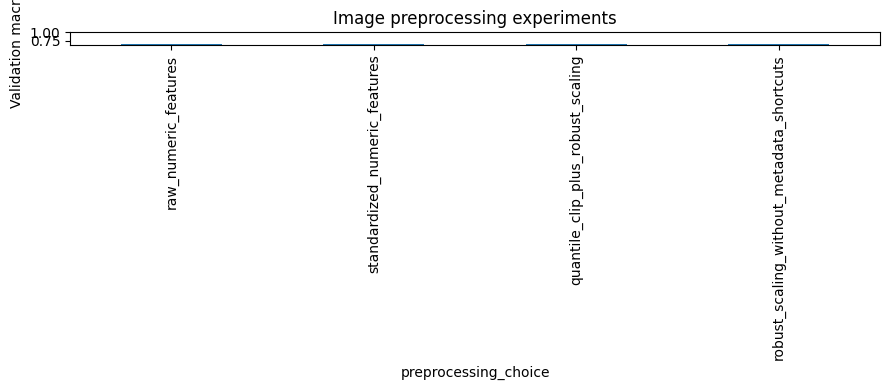

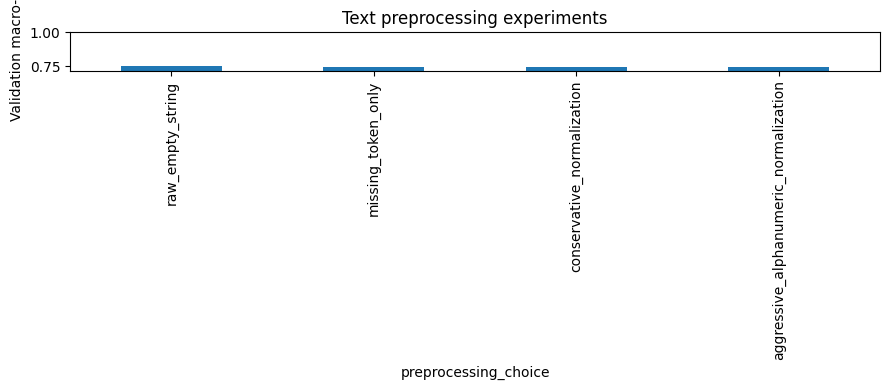

,train,validation
rows,9000,2500
missing_text,100,30
low_resolution,760,202
low_sharpness,450,125


In [2]:
for modality, group in experiments.groupby("modality"):
    ax = group.plot.bar(
        x="preprocessing_choice",
        y="macro_f1",
        ylim=(max(0, group["macro_f1"].min() - 0.03), 1),
        title=f"{modality.title()} preprocessing experiments",
        legend=False,
        figsize=(9, 4),
    )
    ax.set_ylabel("Validation macro-F1")
    plt.tight_layout()
    plt.show()

display(
    pd.DataFrame({
        "train": [
            len(train),
            int(train["text_was_missing"].sum()),
            int(train["image_low_resolution"].sum()),
            int(train["image_low_sharpness"].sum()),
        ],
        "validation": [
            len(validation),
            int(validation["text_was_missing"].sum()),
            int(validation["image_low_resolution"].sum()),
            int(validation["image_low_sharpness"].sum()),
        ],
    }, index=[
        "rows", "missing_text", "low_resolution", "low_sharpness"
    ])
)


## Selected Pipeline

- Text: `missing_token_only`
- Images: EXIF transpose, RGB conversion, aspect-preserving resize, padding,
  tensor conversion, and normalization.
- Quality issues are retained as flags rather than deleted.

## Final Conclusion

Selected text pipeline: missing_token_only. Best text experiment macro-F1=0.7475; raw text baseline=0.7475. Best image-statistics preprocessing=raw_numeric_features with macro-F1=0.6733; raw image-feature baseline=0.6733. All rows were retained. Images remain unchanged on disk and will be loaded with EXIF-safe RGB conversion, aspect-preserving resize, padding, and normalization. Destructive sharpening, deletion, and aggressive cropping were rejected.
